# DVR + Complex Scaling Test to Locate Resonance
## True resonance located at: $E_\text{res}=1.606-i0.047$.

In [6]:
from src.dvr import *

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
save_plots = True
plots_folder = Path("./plots/locate_resonance_wCS")
plots_folder.mkdir(exist_ok=True, parents=True)

In [7]:
# define system parameters
n = 256                      # number of DVR grid points
phi = np.pi / 24                # rotation angle
real_res = 1.606 - 1j*0.047  # expected value of resonance
L = 50.0                     # system size

gauss_s = lambda r: 2.0 * np.exp(-((r-3.0)/1.5)**2) # potential

In [8]:
# grab energy spectrum using DVR basis with complex scaling
DVRtest = DVR(n, L, rotation_angle=phi, potential=gauss_s)
eigvals, _ = DVRtest.eig()

# grab the eigenpair that's closest to the expected 
# resonance value and compute its radius
resonance_energy, resonance_state = DVRtest.closest_to_resonance(real_res)
resonance_energy = resonance_energy[0]
resonance_rr = DVRtest.compute_rr(resonance_state[:, 0], rotate_rr=True)

print(f"DVR calculation computes resonance as E = {resonance_energy.real:.3f} + i{resonance_energy.imag:.3f}.")
print(f"DVR calculation computes radius of resonance as <r^2> = {resonance_rr.real:.3f} + i{resonance_rr.imag:.3f}.")

DVR calculation computes resonance as E = 1.606 + i-0.047.
DVR calculation computes radius of resonance as <r^2> = 0.774 + i0.200.


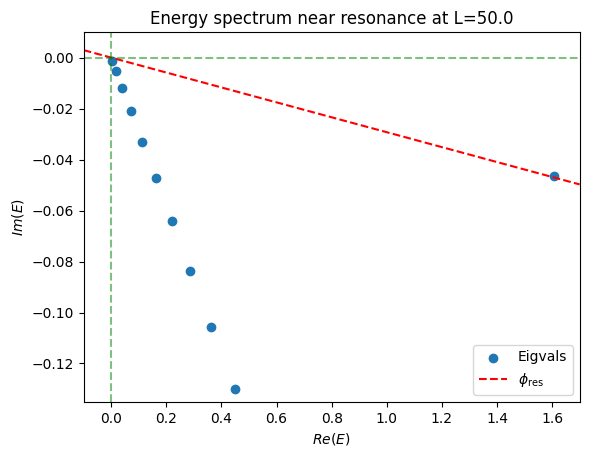

In [11]:
# plot full energy spectrum including
# continuum branch and resonance
fig, ax = plt.subplots()
ax.scatter(np.real(eigvals), np.imag(eigvals), label="Eigvals")
ax.set_xlabel(r"$Re(E)$")
ax.set_ylabel(r"$Im(E)$")
ax.set_title(f"Energy spectrum near resonance at L={L}")
ax.set_xlim([-0.1, 1.7])
ax.set_ylim([-0.135, 0.01])

# plot line at angle phi
# rough angle: phi = 0.0292569048 or pi/107
slope = -1.0 * np.tan(0.0292569048)
ax.axline((0, 0), slope=slope, color='red', linestyle='--', label=r"$\phi_\text{res}$")
plt.axvline(0, linestyle='--', color='green', alpha=0.5)
plt.axhline(0, linestyle='--', color='green', alpha=.5)
ax.legend()

if save_plots:
    plt.savefig(plots_folder / "energy_spectrum__phi_{phi:.3f}.png")
plt.show()

### Use DVR to find energy of eigval closest to resonance for multiple $\phi$
$E(\phi)$ should be constant.

In [14]:
phis = np.linspace(pi/24, pi/6, 50)
Es = []

for phi in phis:
    DVRtest = DVR(n, L, rotation_angle=phi, potential=gauss_s)
    eigval, _ = DVRtest.closest_to_resonance(real_res)
    Es.append(eigval)

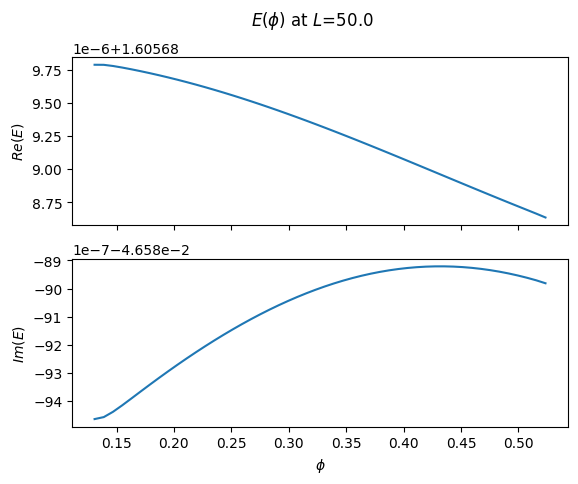

In [15]:
# plot <r^2>(phi)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(phis, np.real(Es), label=r"$Re(E)$")
ax2.plot(phis, np.imag(Es), label=r"$Im(E)$")
ax1.set_ylabel(r"$Re(E)$")
ax2.set_ylabel(r"$Im(E)$")
ax2.set_xlabel(r"$\phi$")
fig.suptitle(r"$E(\phi)$ at $L$=50.0")
if save_plots:
    plt.savefig(plots_folder / "exact_energy_vs_phi.png")
plt.show()